In [75]:
import os
import numpy as np
import pandas as pd


# Location of data:
location = r'D:\tacc scratch\25_03\18\2bc42c69-0ff8-433b-b5b5-68350caf503c-007'

# Load dakotaTab.out file, which is inside the location + results
dakotaTabPath = os.path.join(location, 'results', 'dakotaTab.out')
dakotaTab = pd.read_csv(dakotaTabPath, sep='\s+')

# Load dakotaTabPrior.out file, which is inside the location + results
'''dakotaTabPriorPath = os.path.join(location, 'results', 'dakotaTabPrior.out')
dakotaTabPrior = pd.read_csv(dakotaTabPriorPath, sep='\s+')

# Merge both since they have the same columns
dakotaTab = pd.concat([dakotaTab, dakotaTabPrior], ignore_index=True)'''


"dakotaTabPriorPath = os.path.join(location, 'results', 'dakotaTabPrior.out')\ndakotaTabPrior = pd.read_csv(dakotaTabPriorPath, sep='\\s+')\n\n# Merge both since they have the same columns\ndakotaTab = pd.concat([dakotaTab, dakotaTabPrior], ignore_index=True)"

In [76]:
# Load cal_file.csv which is inside the location
calFilePath = os.path.join(location, 'cal_file.csv')
calFile = pd.read_csv(calFilePath, header=None)

maxForce = max(calFile.iloc[0])
# Get maxForce as the maximum value in the calFile
# maxForce = np.array(calFile).max()

# Get length of the calFile
calFileLength = calFile.shape[1]
print(f'calFileLength: {calFileLength}')

# extract the last calFileLength columns from dakotaTab
dakotaTabForce = dakotaTab.iloc[:, -calFileLength:]

# Get a matrix of residuals by subtracting the calFile to each row of dakotaTabForce
residuals = (dakotaTabForce.values - calFile.values[:, None]) / maxForce
residuals = np.abs(residuals)[0]

# Get the mean of each row
residuals = np.mean(residuals, axis=1)

print(residuals)
print(len(residuals))

# If residual is larger than 1, set the value to 1
residuals[residuals > 1] = 1

calFileLength: 495
[0.07551431 0.07706734 0.07601672 0.0745052  0.07659156 0.08170829
 0.08124479 0.0766264  0.07901687 0.0767792  0.0777512  0.07734872
 0.0784766  0.07702742 0.07572282 0.07562765 0.0766613  0.0767083
 0.08179483 0.07494402 0.07499049 0.07747769 0.07697293 0.07329507
 0.07689163 0.07673396 0.07923504 0.07668756 0.07429515 0.07555899
 0.07959488 0.07859806 0.07938689 0.07840476 0.07660059 0.07681631
 0.07581187 0.07831187 0.07363097 0.07685807 0.08152707 0.07776622
 0.07597558 0.07654312 0.07809243 0.07838113 0.07562149 0.07537488
 0.07586289 0.07637878 0.07529401 0.07610703 0.0756802  0.07698382
 0.07668467 0.07558681 0.07552922 0.07675631 0.07542333 0.0755239
 0.08232092 0.07821552 0.07575745 0.07866654 0.07573431 0.07841676
 0.07897853 0.07520631 0.0760121  0.07484742 0.07741651 0.07526369
 0.07655326 0.07611527 0.07675681 0.07718846 0.07777534 0.07758911
 0.07563466 0.07728726 0.07669007 0.07703692 0.07539792 0.07912452
 0.07536419 0.07617062 0.07773235 0.07677415 

In [77]:
# Take this residuals and add it as a new column to dakotaTab
dakotaTab['residuals'] = residuals

In [78]:
dakotaTab.columns

Index(['eval_id', 'interface', 'gamma', 'kappa', 'eta1', 'sig', 'lam', 'mup',
       'sigp', 'rsmax',
       ...
       'force_487', 'force_488', 'force_489', 'force_490', 'force_491',
       'force_492', 'force_493', 'force_494', 'force_495', 'residuals'],
      dtype='object', length=513)

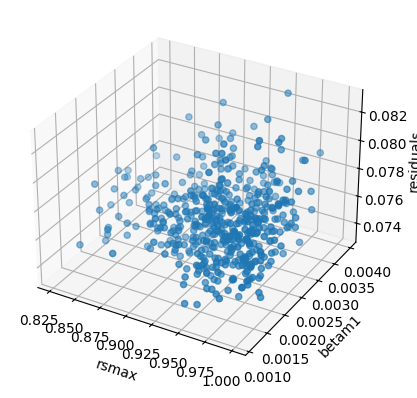

In [79]:
# Create a plot of gamma vs residuals
import matplotlib.pyplot as plt

param_x = 'rsmax'
param_y = 'betam1'
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(dakotaTab[param_x], dakotaTab[param_y], dakotaTab['residuals'])
ax.set_xlabel(param_x)
ax.set_ylabel(param_y)
ax.set_zlabel('residuals')
plt.show()